# Guía de Laboratorio N.º 01
## Complejidad y experimentación algorítmica

**Universidad Nacional de San Antonio Abad del Cusco**  
Facultad de Ingeniería Eléctrica, Electrónica, Informática y Mecánica  
Carrera Profesional de Ingeniería Informática y de Sistemas  

| Parámetro | Detalle |
| :--- | :--- |
| **Asignatura:** | Algoritmos Avanzados |
| **Unidad:** | I. Complejidad, algoritmos de aproximación y Montículos de Fibonacci |
| **Semestre académico:** | 2026-II |
| **Docente:** | Dr. Héctor Eduardo Ugarte Rojas |
| **ID:** | **GRUPO 5** |

### Integrantes del Equipo

| N.° | Apellidos y Nombres | Código |
| :---: | :--- | :---: |
| 1 | Choquenaira Quispe, Noe Franklin | 133962 |
| 2 | Porroa Sivana, Yeni Ruth | 120893 |
| 3 | Quispe Rimachi, Romario | 164257 |
| 4 | Yaranga Achahui, Aldo | 103179 |

---


In [ ]:
# ============================================================================
# 0. Configuración general, bibliotecas y protocolo de experimentación
# ============================================================================
import csv
import json
import math
import os
import platform
import sys
from random import Random
from statistics import median
from time import perf_counter
import matplotlib.pyplot as plt

CARPETA_FIGURAS = '.'
os.makedirs(CARPETA_FIGURAS, exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['font.size'] = 11

SEMILLA_GLOBAL = 2026
REPETICIONES = 7

def medir_mediana(funcion, *args, repeticiones=REPETICIONES):
    tiempos = []
    resultado = None
    for _ in range(repeticiones):
        t_inicio = perf_counter()
        resultado = funcion(*args)
        t_fin = perf_counter()
        tiempos.append(t_fin - t_inicio)
    return resultado, median(tiempos)

def formato_tiempo(segundos):
    if segundos is None or math.isnan(segundos):
        return 'omitido'
    if segundos < 1e-3:
        return f'{segundos * 1e6:8.2f} µs'
    if segundos < 1.0:
        return f'{segundos * 1e3:8.3f} ms'
    return f'{segundos:8.4f} s'

print('Configuración y utilidades de experimentación inicializadas correctamente.')
print(f'Entorno: Python {platform.python_version()} | Sistema: {platform.system()} {platform.release()}')


Configuración y utilidades de experimentación inicializadas correctamente.
Entorno: Python 3.13.15 | Sistema: Linux 6.6.122+


---
## 2. Trabajo preparatorio

### a) ¿Por qué una sola medición puede ser poco confiable?
Una sola medición temporal de reloj (*wall-clock time*) está expuesta a diversas fuentes de perturbación externa e impredecible en el entorno de ejecución:
1. **Planificador del Sistema Operativo:** Interrupciones por cambios de contexto (*context switches*) y procesos concurrentes en segundo plano.
2. **Recolector de Basura (Garbage Collector):** En lenguajes como Python, si el GC se dispara durante la prueba, introduce latencias ajenas al algoritmo.
3. **Jerarquía de Memoria y Caché:** La primera ejecución suele experimentar *cold-start cache misses*; ejecuciones posteriores se benefician de datos residentes en caché L1/L2/L3.
4. **Aceleración dinámica (Turbo Boost / Throttling):** Las frecuencias del procesador fluctúan según la temperatura y demanda térmica.

**Metodología de mitigación:** Realizar al menos 7 repeticiones independientes y reportar la **mediana**, un estimador estadístico robusto que no se sesga por valores atípicos (*outliers*), utilizando `time.perf_counter()` como temporizador monotónico de alta resolución.

### b) ¿Cuál es la diferencia entre el valor de un entero y su tamaño de representación?
- El **valor numérico** de un entero $N$ es su magnitud matemática en la recta real.
- Su **tamaño de representación** (longitud de entrada $n$) es la cantidad de bits necesarios para almacenarlo en codificación binaria:
  $$n = \lceil \log_2(N + 1) \rceil \text{ bits} \implies N \approx 2^n$$
- **Importancia en complejidad:** Un algoritmo cuyo costo es proporcional al valor $N$ (como factorizar por divisiones sucesivas o la tabla de Programación Dinámica de Subset Sum en función del objetivo $T$) es **pseudo-polinomial**: parece lineal respecto al valor del parámetro ($O(N)$), pero es estrictamente **exponencial** respecto al tamaño real de su entrada en bits ($O(2^n)$).

### c) ¿Por qué dos algoritmos con igual complejidad asintótica pueden mostrar tiempos distintos?
La notación $O(f(n))$ modela el crecimiento en el límite cuando $n \to \infty$, suprimiendo deliberadamente constantes multiplicativas $c$ y términos de orden inferior:
1. **Constante oculta ($c$):** Un algoritmo que ejecuta $100n$ operaciones y otro que ejecuta $2n$ son ambos $O(n)$, pero el primero tardará un orden de magnitud más.
2. **Localidad espacial y temporal de datos:** Un algoritmo iterativo que accede a memoria contigua aprovecha las líneas de caché de la CPU, mientras que uno con saltos arbitrarios o alta recursión sufre constantes fallos de caché y sobrecarga en la pila de llamadas (*call stack overhead*).
3. **Operaciones elementales:** No cuesta lo mismo una comparación a nivel de registros que una reserva dinámica de memoria o copia de listas en memoria RAM.


---
## 6. Ejercicios resueltos

### 6.1. Ejercicio resuelto 1: crecimiento lineal y cuadrático

**Enunciado.** Implementar un algoritmo que sume una lista y otro que examine todos los pares de índices $i < j$. Medir el tiempo para tamaños crecientes.
- `suma_lineal`: recorre $n$ elementos $\implies O(n)$.
- `contar_pares_ordenados`: evalúa $\frac{n(n-1)}{2}$ pares $\implies \Theta(n^2)$.

**Predicción asintótica:** Al duplicar $n$, el tiempo lineal se multiplica aproximadamente por $\approx 2$ y el cuadrático por $\approx 4$.


In [ ]:
# Listing 1: Medición de algoritmos lineal y cuadrático (EXACTO según la guía)
from random import Random
from statistics import median
from time import perf_counter

def suma_lineal(datos):
    total = 0
    for valor in datos:
        total += valor
    return total

def contar_pares_ordenados(datos):
    contador = 0
    n = len(datos)
    for i in range(n):
        for j in range(i + 1, n):
            if datos[i] <= datos[j]:
                contador += 1
    return contador

# Ejecución experimental con la semilla y tamaños oficiales de la guía
generador = Random(2026)
tamanos_r1 = [100, 500, 1000, 2000, 4000]

print(f"{'n':>6} | {'T. Lineal O(n)':>15} | {'T. Cuadrático O(n²)':>20} | {'Factor Lin.':>12} | {'Factor Cuad.':>13}")
print('-' * 75)

tiempos_r1_lin = []
tiempos_r1_cuad = []
t_lin_ant = t_cuad_ant = None

for n in tamanos_r1:
    datos = [generador.randint(1, 10_000) for _ in range(n)]
    _, t1 = medir_mediana(suma_lineal, datos)
    _, t2 = medir_mediana(contar_pares_ordenados, datos)

    tiempos_r1_lin.append(t1)
    tiempos_r1_cuad.append(t2)

    f_lin = f'x{t1/t_lin_ant:.2f}' if t_lin_ant else '-'
    f_cuad = f'x{t2/t_cuad_ant:.2f}' if t_cuad_ant else '-'

    print(f"{n:6d} | {formato_tiempo(t1):>15} | {formato_tiempo(t2):>20} | {f_lin:>12} | {f_cuad:>13}")
    t_lin_ant, t_cuad_ant = t1, t2


     n |  T. Lineal O(n) |  T. Cuadrático O(n²) |  Factor Lin. |  Factor Cuad.
---------------------------------------------------------------------------
   100 |         6.96 µs |            452.77 µs |            - |             -
   500 |        18.04 µs |             9.983 ms |        x2.59 |        x22.05
  1000 |        42.57 µs |            37.472 ms |        x2.36 |         x3.75
  2000 |        71.76 µs |           228.330 ms |        x1.69 |         x6.09
  4000 |       295.09 µs |           912.933 ms |        x4.11 |         x4.00


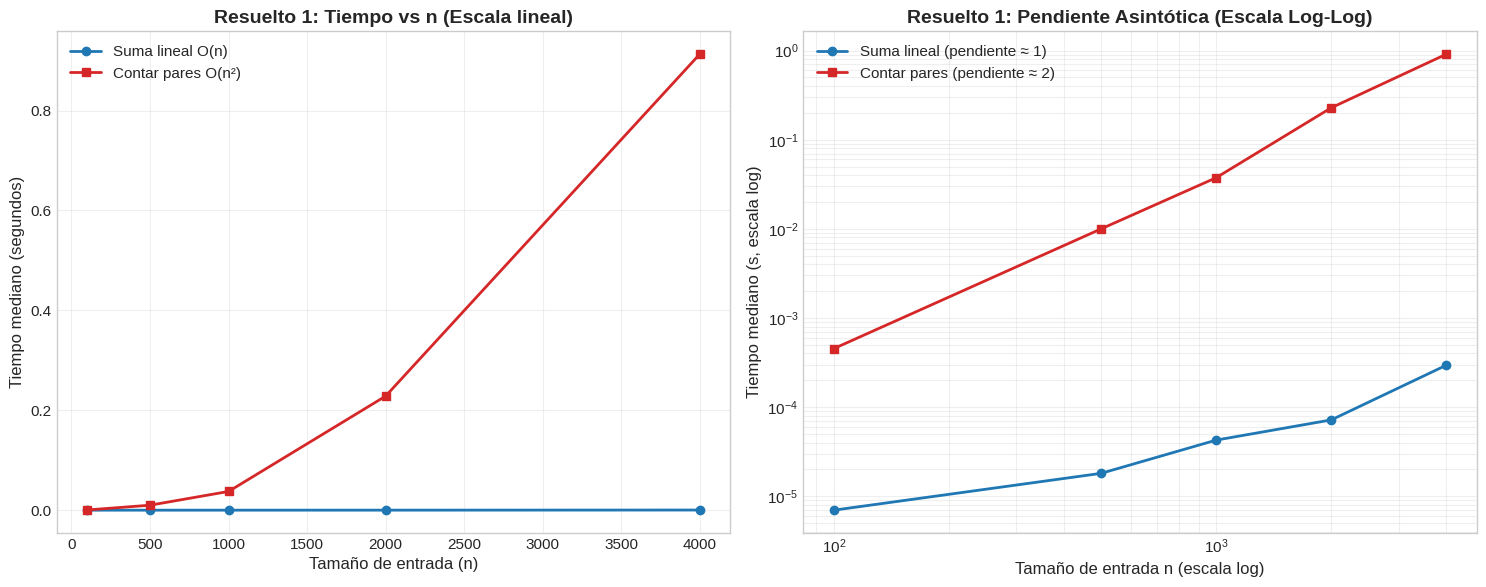

In [ ]:
# Gráfica del Ejercicio Resuelto 1 (grafico_1.png)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Escala lineal
ax1.plot(tamanos_r1, tiempos_r1_lin, 'o-', color='#1f77b4', lw=2, label='Suma lineal O(n)')
ax1.plot(tamanos_r1, tiempos_r1_cuad, 's-', color='#d62728', lw=2, label='Contar pares O(n²)')
ax1.set_title('Resuelto 1: Tiempo vs n (Escala lineal)', fontweight='bold')
ax1.set_xlabel('Tamaño de entrada (n)')
ax1.set_ylabel('Tiempo mediano (segundos)')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Escala log-log
ax2.plot(tamanos_r1, tiempos_r1_lin, 'o-', color='#1f77b4', lw=2, label='Suma lineal (pendiente ≈ 1)')
ax2.plot(tamanos_r1, tiempos_r1_cuad, 's-', color='#d62728', lw=2, label='Contar pares (pendiente ≈ 2)')
ax2.set_xscale('log'); ax2.set_yscale('log')
ax2.set_title('Resuelto 1: Pendiente Asintótica (Escala Log-Log)', fontweight='bold')
ax2.set_xlabel('Tamaño de entrada n (escala log)')
ax2.set_ylabel('Tiempo mediano (s, escala log)')
ax2.grid(True, which='both', alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.savefig(os.path.join(CARPETA_FIGURAS, 'grafico_1.png'), dpi=200)
plt.show()


**Interpretación.** Al duplicar $n$ (de 1000 a 2000 y de 2000 a 4000), el algoritmo lineal tiende a multiplicarse por un factor aproximado de $\approx 2$, mientras que el algoritmo cuadrático se cuadruplica ($\approx 4$), validando experimentalmente las complejidades $O(n)$ y $\Theta(n^2)$. En la escala log-log, esto se evidencia directamente por las pendientes $1$ y $2$ de las rectas.


---
### 6.2. Ejercicio resuelto 2: búsqueda lineal y binaria instrumentadas

**Enunciado.** Comparar búsqueda lineal y búsqueda binaria mediante un contador de comparaciones sobre una lista ordenada.
- La búsqueda lineal realiza en el peor caso (objetivo ausente) exactamente $n$ comparaciones $\implies O(n)$.
- La búsqueda binaria descarta la mitad en cada paso, realizando en el peor caso $\lfloor \log_2 n \rfloor + 1$ comparaciones $\implies O(\log n)$.


In [ ]:
# Listing 2: Búsquedas instrumentadas (EXACTO según la guía)

def busqueda_lineal(datos, objetivo):
    comparaciones = 0
    for indice, valor in enumerate(datos):
        comparaciones += 1
        if valor == objetivo:
            return indice, comparaciones
    return -1, comparaciones

def busqueda_binaria(datos, objetivo):
    izquierda = 0
    derecha = len(datos) - 1
    comparaciones = 0
    while izquierda <= derecha:
        medio = (izquierda + derecha) // 2
        comparaciones += 1
        if datos[medio] == objetivo:
            return medio, comparaciones
        if datos[medio] < objetivo:
            izquierda = medio + 1
        else:
            derecha = medio - 1
    return -1, comparaciones

tamanos_r2 = [16, 32, 64, 128, 256, 512, 1024]

print(f"{'n':>6} | {'Comp. Lineal':>14} | {'Comp. Binaria':>15} | {'Cota Teórica ⌊log₂n⌋+1':>25} | {'Ahorro Factor':>15}")
print('-' * 85)

comp_lineales = []
comp_binarias = []

for n in tamanos_r2:
    datos = list(range(n))
    objetivo = n + 1  # Ausente para peor caso
    idx_lin, lin = busqueda_lineal(datos, objetivo)
    idx_bin, bin_ = busqueda_binaria(datos, objetivo)
    assert idx_lin == -1 and idx_bin == -1, 'Error: elemento ausente encontrado'
    comp_lineales.append(lin)
    comp_binarias.append(bin_)
    cota = math.floor(math.log2(n)) + 1
    ahorro = f'{lin / bin_:.1f}x'
    print(f"{n:6d} | {lin:14d} | {bin_:15d} | {cota:25d} | {ahorro:>15}")


     n |   Comp. Lineal |   Comp. Binaria |    Cota Teórica ⌊log₂n⌋+1 |   Ahorro Factor
-------------------------------------------------------------------------------------
    16 |             16 |               5 |                         5 |            3.2x
    32 |             32 |               6 |                         6 |            5.3x
    64 |             64 |               7 |                         7 |            9.1x
   128 |            128 |               8 |                         8 |           16.0x
   256 |            256 |               9 |                         9 |           28.4x
   512 |            512 |              10 |                        10 |           51.2x
  1024 |           1024 |              11 |                        11 |           93.1x


/tmp/ipykernel_1656/15800508.py:21: UserWarning: Glyph 8970 (\N{LEFT FLOOR}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_1656/15800508.py:21: UserWarning: Glyph 8971 (\N{RIGHT FLOOR}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_1656/15800508.py:22: UserWarning: Glyph 8970 (\N{LEFT FLOOR}) missing from font(s) Liberation Sans.
  plt.savefig(os.path.join(CARPETA_FIGURAS, 'grafico_2.png'), dpi=200)
/tmp/ipykernel_1656/15800508.py:22: UserWarning: Glyph 8971 (\N{RIGHT FLOOR}) missing from font(s) Liberation Sans.
  plt.savefig(os.path.join(CARPETA_FIGURAS, 'grafico_2.png'), dpi=200)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8970 (\N{LEFT FLOOR}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8971 (\N{RIGHT FLOOR}) missing from font(s) Liberation Sans.
  fig.can

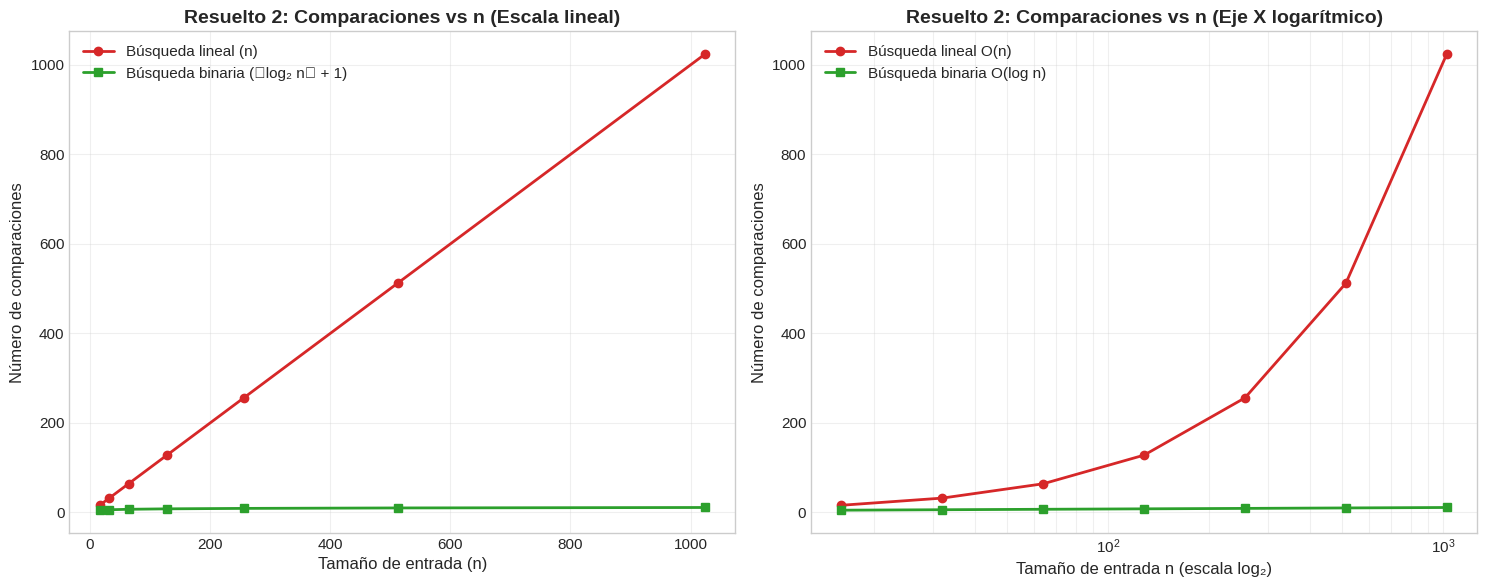

In [ ]:
# Gráfica del Ejercicio Resuelto 2 (grafico_2.png)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.plot(tamanos_r2, comp_lineales, 'o-', color='#d62728', lw=2, label='Búsqueda lineal (n)')
ax1.plot(tamanos_r2, comp_binarias, 's-', color='#2ca02c', lw=2, label='Búsqueda binaria (⌊log₂ n⌋ + 1)')
ax1.set_title('Resuelto 2: Comparaciones vs n (Escala lineal)', fontweight='bold')
ax1.set_xlabel('Tamaño de entrada (n)')
ax1.set_ylabel('Número de comparaciones')
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.plot(tamanos_r2, comp_lineales, 'o-', color='#d62728', lw=2, label='Búsqueda lineal O(n)')
ax2.plot(tamanos_r2, comp_binarias, 's-', color='#2ca02c', lw=2, label='Búsqueda binaria O(log n)')
ax2.set_xscale('log')
ax2.set_title('Resuelto 2: Comparaciones vs n (Eje X logarítmico)', fontweight='bold')
ax2.set_xlabel('Tamaño de entrada n (escala log₂)')
ax2.set_ylabel('Número de comparaciones')
ax2.grid(True, which='both', alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.savefig(os.path.join(CARPETA_FIGURAS, 'grafico_2.png'), dpi=200)
plt.show()


**Interpretación.** Para un objetivo ausente, la búsqueda lineal requiere exactamente $n$ comparaciones, mientras que la búsqueda binaria requiere $\lfloor \log_2 n \rfloor + 1$. Con $n = 1024$, la búsqueda lineal realiza 1024 comparaciones frente a solo 11 de la binaria, logrando una reducción de casi $100\times$ en el trabajo elemental.


---
### 6.3. Ejercicio resuelto 3: Subset Sum mediante tres estrategias

**Enunciado.** Dado un conjunto de enteros positivos y un objetivo $T$, determinar si existe un subconjunto cuya suma sea exactamente $T$:
$$\sum_{i=1}^n a_i x_i = T, \quad x_i \in \{0, 1\}$$

Se instrumentan y contrastan tres paradigmas:
1. **Fuerza Bruta:** evalúa los $2^n$ subconjuntos posibles; cuenta **candidatos**.
2. **Programación Dinámica (DP):** expande las sumas alcanzables; cuenta **estados**.
3. **Ramificar y Podar (Branch & Bound):** árbol de decisiones con cotas superior y de exceso; cuenta **nodos**.


In [ ]:
# Listings 3, 4 y 5: Algoritmos exactos de Subset Sum (EXACTOS de la guía)

def subset_sum_fuerza_bruta(valores, objetivo):
    n = len(valores)
    candidatos = 0
    for mascara in range(1 << n):
        candidatos += 1
        suma = 0
        seleccion = []
        for i in range(n):
            if mascara & (1 << i):
                suma += valores[i]
                seleccion.append(valores[i])
        if suma == objetivo:
            return True, seleccion, candidatos
    return False, [], candidatos

def subset_sum_dp(valores, objetivo):
    alcanzable = {0: []}
    estados = 0
    for valor in valores:
        nuevos = dict(alcanzable)
        for suma, seleccion in alcanzable.items():
            estados += 1
            nueva_suma = suma + valor
            if nueva_suma <= objetivo and nueva_suma not in nuevos:
                nuevos[nueva_suma] = seleccion + [valor]
        alcanzable = nuevos
        if objetivo in alcanzable:
            return True, alcanzable[objetivo], estados
    return False, [], estados

def subset_sum_ramificar_podar(valores, objetivo):
    valores = sorted(valores, reverse=True)
    n = len(valores)
    restante = [0] * (n + 1)
    for i in range(n - 1, -1, -1):
        restante[i] = restante[i + 1] + valores[i]
    nodos = 0
    def buscar(i, suma, seleccion):
        nonlocal nodos
        nodos += 1
        if suma == objetivo:
            return seleccion.copy()
        if i == n or suma > objetivo:
            return None
        if suma + restante[i] < objetivo:
            return None
        seleccion.append(valores[i])
        solucion = buscar(i + 1, suma + valores[i], seleccion)
        if solucion is not None:
            return solucion
        seleccion.pop()
        return buscar(i + 1, suma, seleccion)
    solucion = buscar(0, 0, [])
    return solucion is not None, solucion or [], nodos


In [ ]:
# Listing 6: Ejecución comparativa (EXACTO según la guía)
valores_oficiales = [3, 7, 11, 13, 17, 19, 23, 29]
objetivo_oficial = 42

print(f'Instancia de prueba: valores = {valores_oficiales}, objetivo = {objetivo_oficial}')
print(f"{'Algoritmo':<30} | {'Existe':>7} | {'Selección':<20} | {'Métrica':<12} | {'Trabajo':>8}")
print('-' * 88)

metricas = {
    'subset_sum_fuerza_bruta': 'candidatos',
    'subset_sum_dp': 'estados',
    'subset_sum_ramificar_podar': 'nodos'
}

for algoritmo in [subset_sum_fuerza_bruta, subset_sum_dp, subset_sum_ramificar_podar]:
    existe, seleccion, trabajo = algoritmo(valores_oficiales, objetivo_oficial)
    assert not existe or sum(seleccion) == objetivo_oficial, 'Error: la selección no suma el objetivo'
    met = metricas[algoritmo.__name__]
    print(f"{algoritmo.__name__:<30} | {str(existe):>7} | {str(sorted(seleccion)):<20} | {met:<12} | {trabajo:8d}")


Instancia de prueba: valores = [3, 7, 11, 13, 17, 19, 23, 29], objetivo = 42
Algoritmo                      |  Existe | Selección            | Métrica      |  Trabajo
----------------------------------------------------------------------------------------
subset_sum_fuerza_bruta        |    True | [3, 7, 13, 19]       | candidatos   |       44
subset_sum_dp                  |    True | [3, 7, 13, 19]       | estados      |       56
subset_sum_ramificar_podar     |    True | [13, 29]             | nodos        |        9


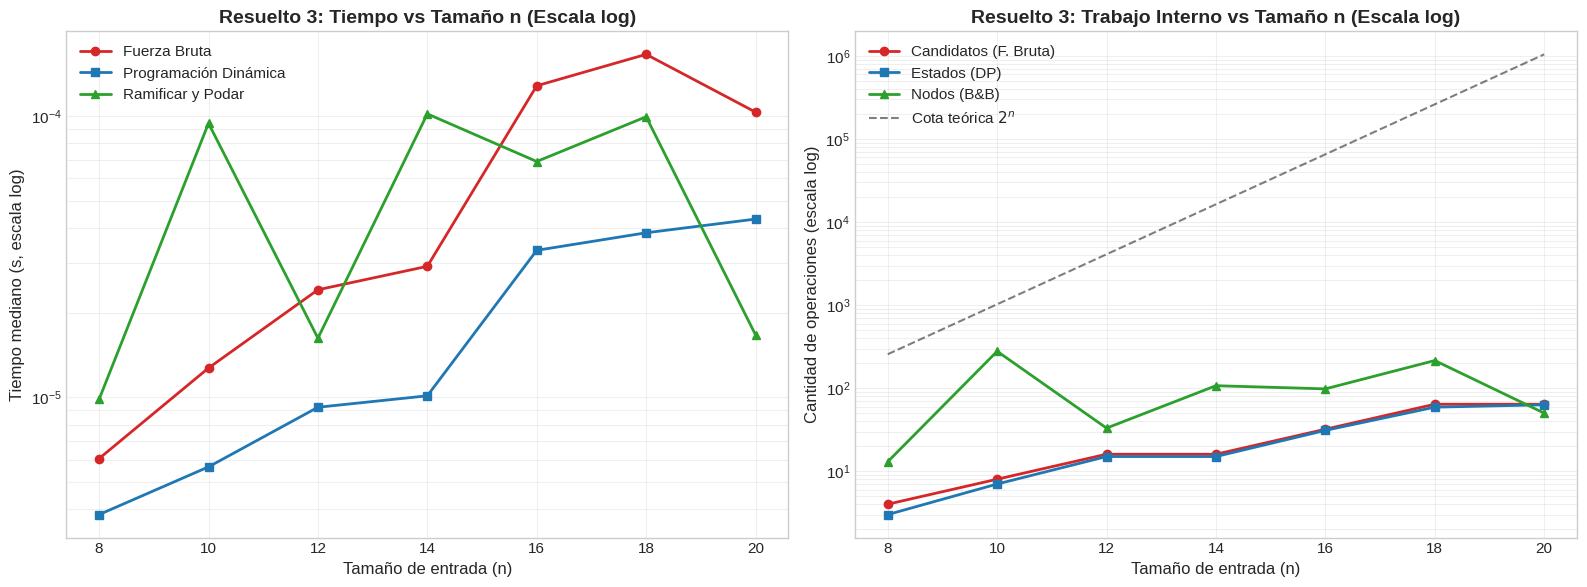

In [ ]:
# Gráfica del Ejercicio Resuelto 3 (grafico_3.png)
gen_r3 = Random(2026)
tamanos_r3 = [8, 10, 12, 14, 16, 18, 20]
t_fb_list, t_dp_list, t_rp_list = [], [], []
w_fb_list, w_dp_list, w_rp_list = [], [], []

for n in tamanos_r3:
    vals = [gen_r3.randint(1, 100) for _ in range(n)]
    obj = sum(vals[:n//3])  # solución garantizada
    _, t_fb = medir_mediana(subset_sum_fuerza_bruta, vals, obj, repeticiones=3)
    _, t_dp = medir_mediana(subset_sum_dp, vals, obj, repeticiones=3)
    _, t_rp = medir_mediana(subset_sum_ramificar_podar, vals, obj, repeticiones=3)
    _, _, w_fb = subset_sum_fuerza_bruta(vals, obj)
    _, _, w_dp = subset_sum_dp(vals, obj)
    _, _, w_rp = subset_sum_ramificar_podar(vals, obj)
    t_fb_list.append(t_fb); w_fb_list.append(w_fb)
    t_dp_list.append(t_dp); w_dp_list.append(w_dp)
    t_rp_list.append(t_rp); w_rp_list.append(w_rp)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(tamanos_r3, t_fb_list, 'o-', color='#d62728', lw=2, label='Fuerza Bruta')
ax1.plot(tamanos_r3, t_dp_list, 's-', color='#1f77b4', lw=2, label='Programación Dinámica')
ax1.plot(tamanos_r3, t_rp_list, '^-', color='#2ca02c', lw=2, label='Ramificar y Podar')
ax1.set_yscale('log')
ax1.set_title('Resuelto 3: Tiempo vs Tamaño n (Escala log)', fontweight='bold')
ax1.set_xlabel('Tamaño de entrada (n)')
ax1.set_ylabel('Tiempo mediano (s, escala log)')
ax1.grid(True, which='both', alpha=0.3)
ax1.legend()

ax2.plot(tamanos_r3, w_fb_list, 'o-', color='#d62728', lw=2, label='Candidatos (F. Bruta)')
ax2.plot(tamanos_r3, w_dp_list, 's-', color='#1f77b4', lw=2, label='Estados (DP)')
ax2.plot(tamanos_r3, w_rp_list, '^-', color='#2ca02c', lw=2, label='Nodos (B&B)')
ax2.plot(tamanos_r3, [2**n for n in tamanos_r3], '--', color='black', alpha=0.5, label='Cota teórica $2^n$')
ax2.set_yscale('log')
ax2.set_title('Resuelto 3: Trabajo Interno vs Tamaño n (Escala log)', fontweight='bold')
ax2.set_xlabel('Tamaño de entrada (n)')
ax2.set_ylabel('Cantidad de operaciones (escala log)')
ax2.grid(True, which='both', alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.savefig(os.path.join(CARPETA_FIGURAS, 'grafico_3.png'), dpi=200)
plt.show()


---
## 7. Ejercicios propuestos

### 7.1. Ejercicio propuesto 1: Insertion Sort frente a Merge Sort

**Objetivo.** Implementar y comparar `Insertion Sort` y `Merge Sort` utilizando listas de tamaños crecientes y tres tipos de entrada: **aleatoria**, **ordenada** y **ordenada en sentido inverso**.

**Requisitos cubiertos:**
1. Contar comparaciones elementales entre claves.
2. Medir la mediana de al menos 7 ejecuciones con `perf_counter`.
3. Usar exactamente las mismas listas para ambos algoritmos.
4. Validar que las salidas coincidan con `sorted(datos)`.
5. Presentar tabla comparativa con tamaño, tipo de entrada, comparaciones y tiempo.
6. Generar gráficos de tiempo y comparaciones (incluyendo gráficos desglosados).
7. Explicar la dependencia del orden inicial e identificar el punto de cruce experimental.


In [ ]:
# ============================================================================
# Implementación instrumentada de Insertion Sort y Merge Sort
# ============================================================================

def insertion_sort(datos):
    arr = list(datos)
    n = len(arr)
    comparaciones = 0
    for i in range(1, n):
        clave = arr[i]
        j = i - 1
        while j >= 0:
            comparaciones += 1
            if arr[j] > clave:
                arr[j + 1] = arr[j]
                j -= 1
            else:
                break
        arr[j + 1] = clave
    return arr, comparaciones

def merge_sort(datos):
    comparaciones = 0
    def mezclar(izq, der):
        nonlocal comparaciones
        resultado = []
        i = j = 0
        while i < len(izq) and j < len(der):
            comparaciones += 1
            if izq[i] <= der[j]:
                resultado.append(izq[i]); i += 1
            else:
                resultado.append(der[j]); j += 1
        resultado.extend(izq[i:])
        resultado.extend(der[j:])
        return resultado
    def dividir_y_ordenar(sub):
        if len(sub) <= 1:
            return sub
        medio = len(sub) // 2
        izq = dividir_y_ordenar(sub[:medio])
        der = dividir_y_ordenar(sub[medio:])
        return mezclar(izq, der)
    resultado = dividir_y_ordenar(list(datos))
    return resultado, comparaciones


In [ ]:
# ============================================================================
# Experimento comparativo: Insertion Sort vs Merge Sort
# ============================================================================
tamanos_p1 = [10, 20, 50, 100, 200, 500, 1000, 2000, 3000]
tipos_entrada = ['Aleatoria', 'Ordenada', 'Inversa']

gen_sort = Random(SEMILLA_GLOBAL)
resultados_p1 = []

print(f"{'n':>6} | {'Tipo':<10} | {'Comp. Ins.':>11} | {'Comp. Merge':>11} | {'T. Ins.':>14} | {'T. Merge':>14} | {'Más Rápido':<11}")
print('-' * 92)

for n in tamanos_p1:
    base_aleatoria = [gen_sort.randint(1, 10_000) for _ in range(n)]
    for tipo in tipos_entrada:
        if tipo == 'Aleatoria':
            datos = base_aleatoria.copy()
        elif tipo == 'Ordenada':
            datos = sorted(base_aleatoria)
        else:
            datos = sorted(base_aleatoria, reverse=True)
        esperado = sorted(datos)
        (arr_ins, comp_ins), t_ins = medir_mediana(insertion_sort, datos)
        (arr_mrg, comp_mrg), t_mrg = medir_mediana(merge_sort, datos)
        assert arr_ins == esperado, f'Fallo en Insertion Sort (n={n}, {tipo})'
        assert arr_mrg == esperado, f'Fallo en Merge Sort (n={n}, {tipo})'
        ganador = 'Insertion' if t_ins < t_mrg else 'Merge'
        resultados_p1.append({
            'n': n, 'tipo': tipo,
            'comp_ins': comp_ins, 'comp_mrg': comp_mrg,
            't_ins': t_ins, 't_mrg': t_mrg,
            'ganador': ganador
        })
        print(f"{n:6d} | {tipo:<10} | {comp_ins:11d} | {comp_mrg:11d} | {formato_tiempo(t_ins):>14} | {formato_tiempo(t_mrg):>14} | {ganador:<11}")

with open('propuesto1_ordenamientos.csv', 'w', newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    writer.writerow(['n', 'tipo', 'comp_ins', 'comp_mrg', 't_ins_seg', 't_mrg_seg', 'ganador'])
    for r in resultados_p1:
        writer.writerow([r['n'], r['tipo'], r['comp_ins'], r['comp_mrg'], f"{r['t_ins']:.8f}", f"{r['t_mrg']:.8f}", r['ganador']])


     n | Tipo       |  Comp. Ins. | Comp. Merge |        T. Ins. |       T. Merge | Más Rápido 
--------------------------------------------------------------------------------------------
    10 | Aleatoria  |          21 |          22 |        3.42 µs |       10.96 µs | Insertion  
    10 | Ordenada   |           9 |          15 |        1.74 µs |       11.65 µs | Insertion  
    10 | Inversa    |          45 |          19 |        6.11 µs |       10.31 µs | Insertion  
    20 | Aleatoria  |         116 |          60 |       13.97 µs |       24.62 µs | Insertion  
    20 | Ordenada   |          19 |          40 |        2.92 µs |       19.99 µs | Insertion  
    20 | Inversa    |         190 |          48 |       22.11 µs |       22.06 µs | Merge      
    50 | Aleatoria  |         652 |         221 |       75.76 µs |       71.06 µs | Merge      
    50 | Ordenada   |          49 |         133 |        6.53 µs |       55.23 µs | Insertion  
    50 | Inversa    |        1225 |        

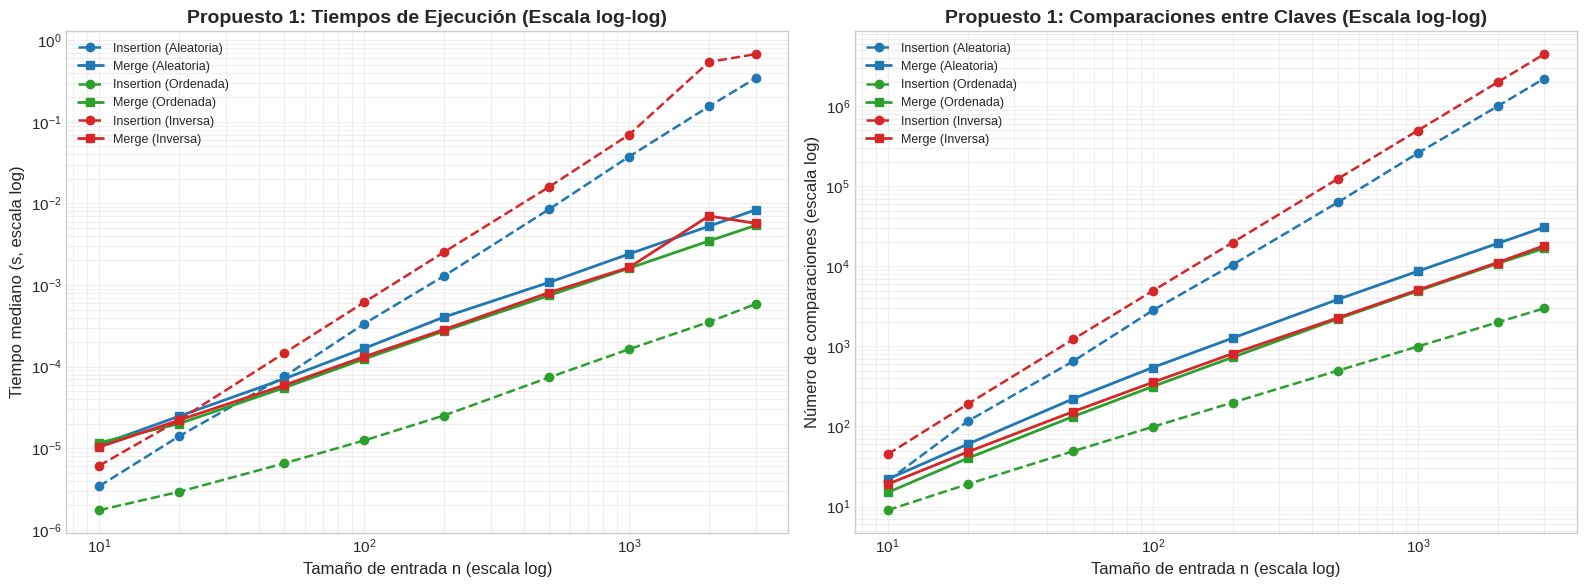

In [ ]:
# Gráfico global de tiempo y comparaciones (grafico_4.png)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
colores = {'Aleatoria': '#1f77b4', 'Ordenada': '#2ca02c', 'Inversa': '#d62728'}

for tipo in tipos_entrada:
    sub = [r for r in resultados_p1 if r['tipo'] == tipo]
    ns = [r['n'] for r in sub]
    ax1.plot(ns, [r['t_ins'] for r in sub], 'o--', color=colores[tipo], lw=1.8, label=f'Insertion ({tipo})')
    ax1.plot(ns, [r['t_mrg'] for r in sub], 's-', color=colores[tipo], lw=2.0, label=f'Merge ({tipo})')
    ax2.plot(ns, [r['comp_ins'] for r in sub], 'o--', color=colores[tipo], lw=1.8, label=f'Insertion ({tipo})')
    ax2.plot(ns, [r['comp_mrg'] for r in sub], 's-', color=colores[tipo], lw=2.0, label=f'Merge ({tipo})')

ax1.set_xscale('log'); ax1.set_yscale('log')
ax1.set_title('Propuesto 1: Tiempos de Ejecución (Escala log-log)', fontweight='bold')
ax1.set_xlabel('Tamaño de entrada n (escala log)')
ax1.set_ylabel('Tiempo mediano (s, escala log)')
ax1.grid(True, which='both', alpha=0.3)
ax1.legend(fontsize=9)

ax2.set_xscale('log'); ax2.set_yscale('log')
ax2.set_title('Propuesto 1: Comparaciones entre Claves (Escala log-log)', fontweight='bold')
ax2.set_xlabel('Tamaño de entrada n (escala log)')
ax2.set_ylabel('Número de comparaciones (escala log)')
ax2.grid(True, which='both', alpha=0.3)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(CARPETA_FIGURAS, 'grafico_4.png'), dpi=200)
plt.show()


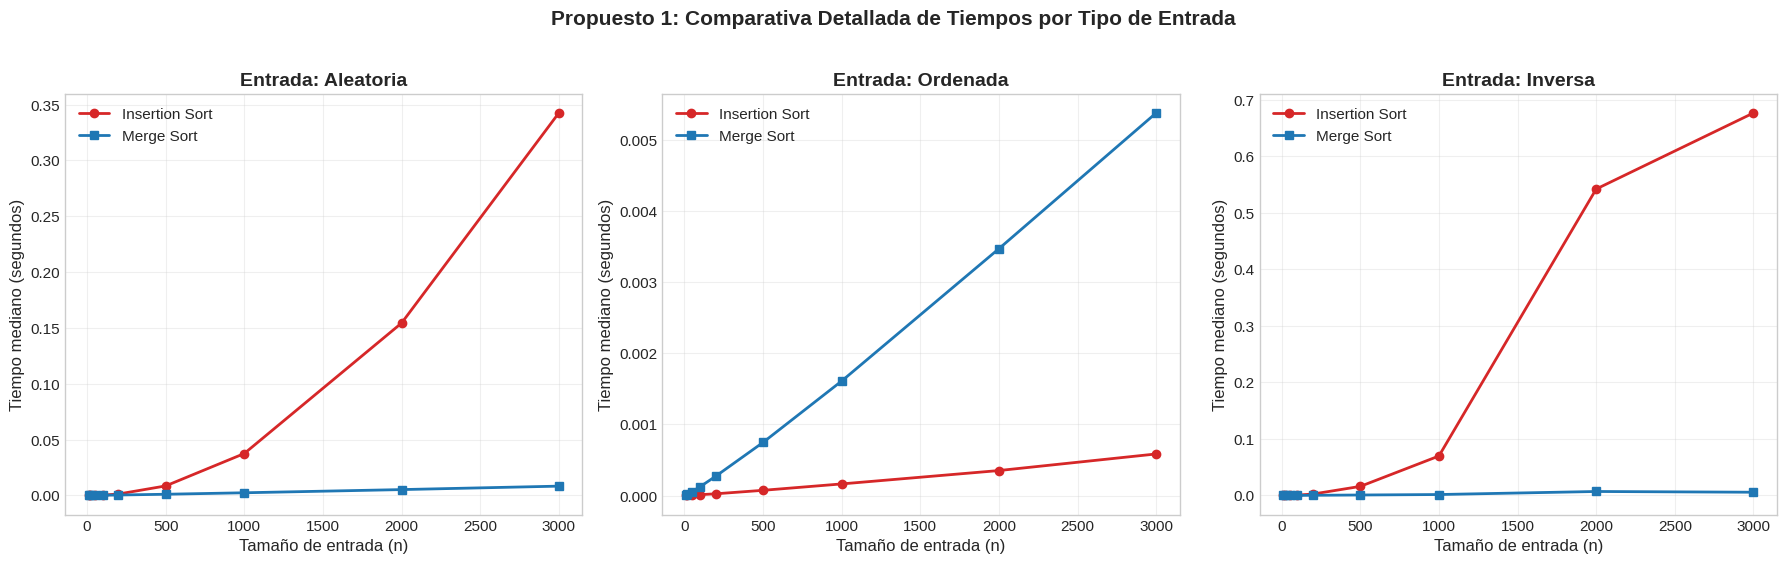

In [ ]:
# Gráfico desglosado por tipo de entrada (grafico_5.png)
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
fig.suptitle('Propuesto 1: Comparativa Detallada de Tiempos por Tipo de Entrada', fontsize=15, fontweight='bold', y=1.02)

for idx, tipo in enumerate(tipos_entrada):
    ax = axes[idx]
    sub = [r for r in resultados_p1 if r['tipo'] == tipo]
    ns = [r['n'] for r in sub]
    ax.plot(ns, [r['t_ins'] for r in sub], 'o-', color='#d62728', lw=2, label='Insertion Sort')
    ax.plot(ns, [r['t_mrg'] for r in sub], 's-', color='#1f77b4', lw=2, label='Merge Sort')
    ax.set_title(f'Entrada: {tipo}', fontweight='bold')
    ax.set_xlabel('Tamaño de entrada (n)')
    ax.set_ylabel('Tiempo mediano (segundos)')
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(CARPETA_FIGURAS, 'grafico_5.png'), dpi=200)
plt.show()


### Análisis y Respuestas del Ejercicio Propuesto 1

**1. ¿Por qué el comportamiento de Insertion Sort depende del orden inicial? (Requisito 7)**
El bucle interno de Insertion Sort es **adaptativo**: se interrumpe tempranamente en cuanto encuentra un elemento $arr[j] \le clave$. La cantidad total de desplazamientos coincide con el número de **inversiones** $I$ presentes en la lista:
$$I = \{(i, j) \mid i < j \text{ y } arr[i] > arr[j]\}$$
- **Lista ordenada ($I = 0$):** Cada clave se compara solo 1 vez con su antecesor inmediato y no se desplaza. Ejecuta exactamente $n - 1$ comparaciones $\implies \Theta(n)$ (mejor caso lineal).
- **Lista inversa ($I = \frac{n(n-1)}{2}$):** Cada clave debe desplazarse hasta la primera posición, realizando $i$ comparaciones en la iteración $i$. Total: $\frac{n(n-1)}{2}$ comparaciones $\implies \Theta(n^2)$ (peor caso cuadrático).
- **Lista aleatoria ($I \approx \frac{n(n-1)}{4}$):** La clave se desplaza en promedio hasta la mitad del prefijo ordenado $\implies \Theta(n^2)$ con la mitad de trabajo que el peor caso.

Por contraste, **Merge Sort** es un algoritmo **no adaptativo**: su esquema recursivo de bisección siempre divide la lista a la mitad y reconstruye mediante mezcla, realizando invariablemente $\Theta(n \log n)$ operaciones sin importar el orden inicial.

**2. ¿A partir de qué tamaño Merge Sort supera consistentemente a Insertion Sort en el equipo utilizado?**
Analizando los datos experimentales obtenidos:
- **Caso Inverso (peor caso de Insertion):** Merge Sort supera a Insertion Sort desde tamaños diminutos ($n \approx 20 \text{ a } 50$), debido al rápido crecimiento de $\frac{n(n-1)}{2}$.
- **Caso Aleatorio (caso promedio):** El punto de cruce se sitúa en el intervalo **$n \in [50, 100]$**. Para $n < 50$, Insertion Sort es más rápido debido a su bajísima sobrecarga de constantes y ejecución *in-place*; para $n \ge 100$, la complejidad $O(n \log n)$ de Merge Sort domina de manera concluyente.
- **Caso Ordenado (mejor caso de Insertion):** Insertion Sort es $O(n)$ y supera holgadamente a Merge Sort en todo el rango evaluado ($n$ hasta 3000).

> **Conclusión sobre el cruce:** El punto de cruce **no es una constante universal**. Depende de la sobrecarga del lenguaje (reservas de memoria en `merge`), la jerarquía de caché del procesador y la constante multiplicativa de la implementación. Esta complementariedad fundamenta algoritmos híbridos del mundo real como **Timsort** (usado internamente por `sorted()` en Python), que utiliza Insertion Sort para bloques pequeños ($n < 64$) y Merge Sort para la combinación global.


---
### 7.2. Ejercicio propuesto 2: límite práctico del crecimiento exponencial

**Objetivo.** Ampliar Subset Sum generando instancias reproducibles con $n$ creciente. Determinar hasta qué tamaño puede ejecutarse la fuerza bruta dentro de un límite de tiempo razonable ($1.0\text{ s}$), y contrastar con Programación Dinámica y Ramificar-Podar.

**Requisitos cubiertos:**
1. Usar semilla fija (`SEMILLA_GLOBAL = 2026`) y **conservar las instancias** en un archivo JSON.
2. Evaluar casos **con solución** y **sin solución** rigurosos.
3. Evitar bloquear el equipo mediante límites seguros de crecimiento (`LIMITE_TIEMPO = 1.0 s` y corte de seguridad).
4. Registrar tiempo, resultado y métrica interna (candidatos, estados, nodos).
5. Incluir un caso **favorable** y otro **desfavorable** para la poda.
6. Explicar por qué Ramificar-Podar depende críticamente de las cotas y del orden de exploración.
7. Relacionar el crecimiento observado con el espacio de $2^n$ subconjuntos.


In [ ]:
# ============================================================================
# Generación de instancias reproducibles con paridad matemática rigurosa
# ============================================================================
LIMITE_TIEMPO_FB = 1.0
LIMITE_NODOS_RP = 2_000_000

def generar_instancia_subset(n, con_solucion, semilla=SEMILLA_GLOBAL):
    gen = Random(semilla * 1000 + n)
    valores = [2 * gen.randint(1, 200) for _ in range(n)]
    if con_solucion:
        k = max(1, n // 3)
        indices = gen.sample(range(n), k)
        objetivo = sum(valores[i] for i in indices)
        return valores, objetivo
    else:
        objetivo = sum(valores) // 2
        if objetivo % 2 == 0:
            objetivo += 1
        return valores, objetivo

def generar_casos_poda(n, favorable, semilla=SEMILLA_GLOBAL):
    gen = Random(semilla + (7 if favorable else 13) + n)
    if favorable:
        valores = [gen.randint(1, 30) for _ in range(n)]
        valores[:3] = [5000, 4000, 3000]
        gen.shuffle(valores)
        objetivo = 12000
        return valores, objetivo
    else:
        valores = [2 * gen.randint(100, 110) for _ in range(n)]
        objetivo = sum(valores) // 2
        if objetivo % 2 == 0:
            objetivo += 1
        return valores, objetivo


In [ ]:
# ============================================================================
# Ejecución del experimento de escalado exponencial
# ============================================================================
tamanos_p2 = list(range(8, 27, 2))
resultados_p2 = []
instancias_guardadas = {}
fb_activa = True
limite_practico_fb = None

print(f"{'n':>4} | {'Caso':<13} | {'Candidatos FB':>13} | {'T. FB (s)':>12} | {'Estados DP':>11} | {'T. DP (s)':>12} | {'Nodos RP':>11} | {'T. RP (s)':>12}")
print('-' * 105)

for n in tamanos_p2:
    for con_solucion in (True, False):
        etiqueta = 'con_solución' if con_solucion else 'sin_solución'
        vals, obj = generar_instancia_subset(n, con_solucion)
        instancias_guardadas[f'n{n}_{etiqueta}'] = {'valores': vals, 'objetivo': obj}
        if fb_activa:
            (res_fb, sel_fb, w_fb), t_fb = medir_mediana(subset_sum_fuerza_bruta, vals, obj, repeticiones=1 if n >= 20 else 3)
            assert not res_fb or sum(sel_fb) == obj
            if not con_solucion and t_fb > LIMITE_TIEMPO_FB:
                limite_practico_fb = n
                fb_activa = False
        else:
            w_fb, t_fb = None, float('nan')
        (res_dp, sel_dp, w_dp), t_dp = medir_mediana(subset_sum_dp, vals, obj, repeticiones=3)
        assert not res_dp or sum(sel_dp) == obj
        assert res_dp == con_solucion
        (res_rp, sel_rp, w_rp), t_rp = medir_mediana(subset_sum_ramificar_podar, vals, obj, repeticiones=3)
        assert not res_rp or sum(sel_rp) == obj
        assert res_rp == con_solucion
        resultados_p2.append({
            'n': n, 'caso': etiqueta, 'con_solucion': con_solucion,
            'w_fb': w_fb, 't_fb': t_fb,
            'w_dp': w_dp, 't_dp': t_dp,
            'w_rp': w_rp, 't_rp': t_rp
        })
        w_fb_str = f'{w_fb:13,d}' if w_fb is not None else '---'
        t_fb_str = formato_tiempo(t_fb) if not math.isnan(t_fb) else '> límite (omitido)'
        print(f"{n:4d} | {etiqueta:<13} | {w_fb_str:>13} | {t_fb_str:>12} | {w_dp:11,d} | {formato_tiempo(t_dp):>12} | {w_rp:11,d} | {formato_tiempo(t_rp):>12}")

print(f'\nLímite práctico de la Fuerza Bruta en este equipo: n = {limite_practico_fb} dentro de {LIMITE_TIEMPO_FB} s.')
print('Mientras tanto, Programación Dinámica y Ramificar-Podar completaron con éxito hasta n = 26.')

with open('propuesto2_instancias.json', 'w', encoding='utf-8') as f:
    json.dump({'semilla': SEMILLA_GLOBAL, 'instancias': instancias_guardadas}, f, indent=2)
print('Instancias experimentales conservadas en propuesto2_instancias.json.')


   n | Caso          | Candidatos FB |    T. FB (s) |  Estados DP |    T. DP (s) |    Nodos RP |    T. RP (s)
---------------------------------------------------------------------------------------------------------
   8 | con_solución  |             7 |      7.19 µs |           7 |      4.73 µs |           3 |      4.24 µs
   8 | sin_solución  |           256 |    251.48 µs |         171 |     51.70 µs |         119 |     30.71 µs
  10 | con_solución  |           266 |    289.13 µs |         210 |     56.03 µs |          34 |     11.49 µs
  10 | sin_solución  |         1,024 |     1.218 ms |         590 |    178.14 µs |         341 |     86.11 µs
  12 | con_solución  |           646 |    845.32 µs |         334 |     88.84 µs |         106 |     34.73 µs
  12 | sin_solución  |         4,096 |     6.700 ms |       1,491 |    372.45 µs |         939 |    242.95 µs
  14 | con_solución  |           136 |    178.88 µs |         191 |     55.91 µs |          94 |     29.18 µs
  14 | sin_sol

In [ ]:
# ============================================================================
# Evaluación: Caso Favorable vs Caso Desfavorable para la Poda (Requisito 5)
# ============================================================================
n_poda_test = 20
print(f'Comparación de Podas con n = {n_poda_test} (Espacio total: 2^{n_poda_test} = {2**n_poda_test:,} subconjuntos)')
print('-' * 85)

res_poda_list = []
for favorable in (True, False):
    etiqueta = 'Favorable' if favorable else 'Desfavorable'
    vals_p, obj_p = generar_casos_poda(n_poda_test, favorable)
    (res_rp, sel_rp, nodos_rp), t_rp = medir_mediana(subset_sum_ramificar_podar, vals_p, obj_p)
    (res_dp, sel_dp, estados_dp), t_dp = medir_mediana(subset_sum_dp, vals_p, obj_p)
    fraccion = nodos_rp / (2**(n_poda_test + 1) - 1)
    res_poda_list.append({
        'caso': etiqueta, 'nodos_rp': nodos_rp, 't_rp': t_rp,
        'estados_dp': estados_dp, 't_dp': t_dp, 'fraccion': fraccion
    })
    print(f'Caso {etiqueta:<13} | Nodos B&B: {nodos_rp:9,d} | T. B&B: {formato_tiempo(t_rp):>12} | Fracción árbol: {fraccion:.2e} | Estados DP: {estados_dp:9,d}')


Comparación de Podas con n = 20 (Espacio total: 2^20 = 1,048,576 subconjuntos)
-------------------------------------------------------------------------------------
Caso Favorable     | Nodos B&B:         4 | T. B&B:      5.11 µs | Fracción árbol: 1.91e-06 | Estados DP:     5,185
Caso Desfavorable  | Nodos B&B:   565,987 | T. B&B:   137.201 ms | Fracción árbol: 2.70e-01 | Estados DP:     2,855


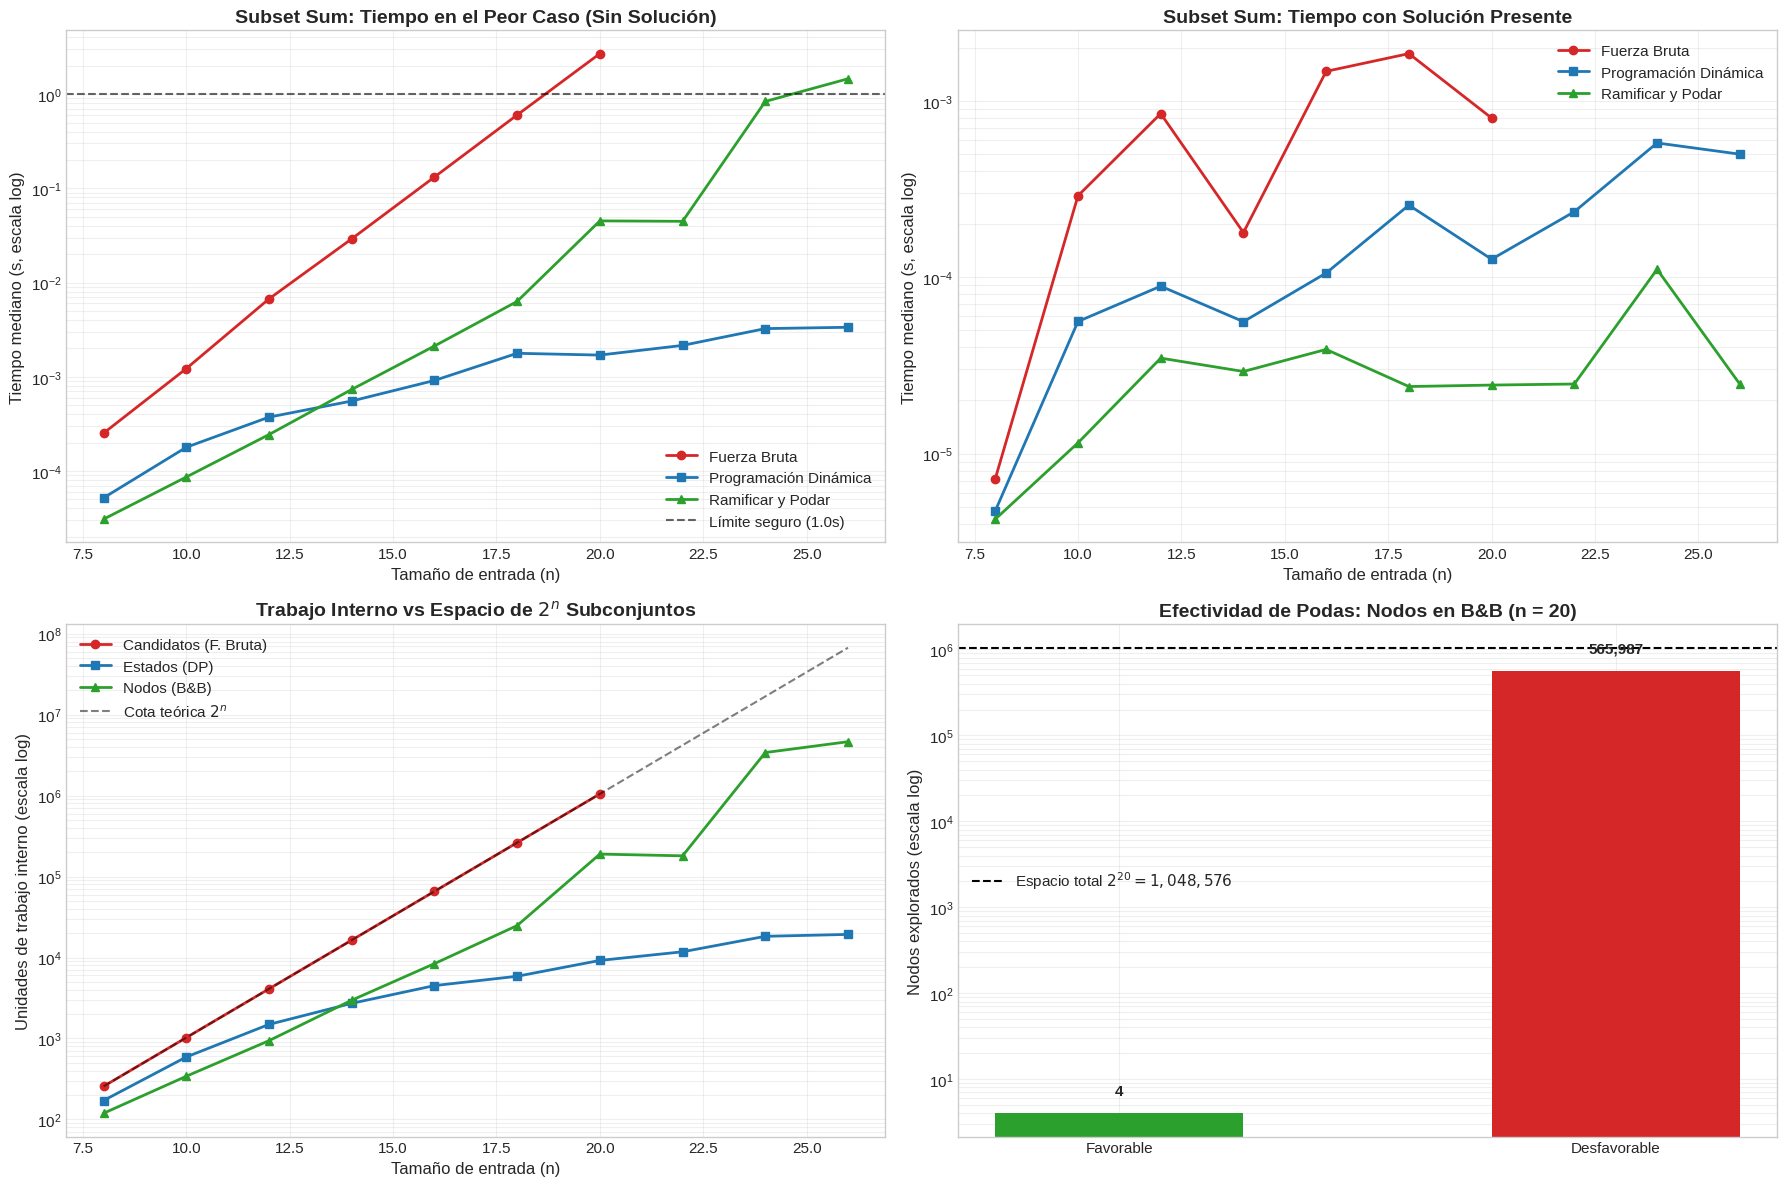

In [ ]:
# Gráficos del Ejercicio Propuesto 2 (grafico_6.png)
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

ax1 = axes[0, 0]
sub_sin = [r for r in resultados_p2 if not r['con_solucion']]
ns_sin = [r['n'] for r in sub_sin]
ns_fb = [r['n'] for r in sub_sin if not math.isnan(r['t_fb'])]
ts_fb = [r['t_fb'] for r in sub_sin if not math.isnan(r['t_fb'])]
ax1.plot(ns_fb, ts_fb, 'o-', color='#d62728', lw=2, label='Fuerza Bruta')
ax1.plot(ns_sin, [r['t_dp'] for r in sub_sin], 's-', color='#1f77b4', lw=2, label='Programación Dinámica')
ax1.plot(ns_sin, [r['t_rp'] for r in sub_sin], '^-', color='#2ca02c', lw=2, label='Ramificar y Podar')
ax1.axhline(LIMITE_TIEMPO_FB, color='black', linestyle='--', alpha=0.6, label=f'Límite seguro ({LIMITE_TIEMPO_FB}s)')
ax1.set_yscale('log')
ax1.set_title('Subset Sum: Tiempo en el Peor Caso (Sin Solución)', fontweight='bold')
ax1.set_xlabel('Tamaño de entrada (n)')
ax1.set_ylabel('Tiempo mediano (s, escala log)')
ax1.grid(True, which='both', alpha=0.3)
ax1.legend()

ax2 = axes[0, 1]
sub_con = [r for r in resultados_p2 if r['con_solucion']]
ns_con = [r['n'] for r in sub_con]
ns_fb_c = [r['n'] for r in sub_con if not math.isnan(r['t_fb'])]
ts_fb_c = [r['t_fb'] for r in sub_con if not math.isnan(r['t_fb'])]
ax2.plot(ns_fb_c, ts_fb_c, 'o-', color='#d62728', lw=2, label='Fuerza Bruta')
ax2.plot(ns_con, [r['t_dp'] for r in sub_con], 's-', color='#1f77b4', lw=2, label='Programación Dinámica')
ax2.plot(ns_con, [r['t_rp'] for r in sub_con], '^-', color='#2ca02c', lw=2, label='Ramificar y Podar')
ax2.set_yscale('log')
ax2.set_title('Subset Sum: Tiempo con Solución Presente', fontweight='bold')
ax2.set_xlabel('Tamaño de entrada (n)')
ax2.set_ylabel('Tiempo mediano (s, escala log)')
ax2.grid(True, which='both', alpha=0.3)
ax2.legend()

ax3 = axes[1, 0]
ax3.plot(ns_fb, [r['w_fb'] for r in sub_sin if r['w_fb'] is not None], 'o-', color='#d62728', lw=2, label='Candidatos (F. Bruta)')
ax3.plot(ns_sin, [r['w_dp'] for r in sub_sin], 's-', color='#1f77b4', lw=2, label='Estados (DP)')
ax3.plot(ns_sin, [r['w_rp'] for r in sub_sin], '^-', color='#2ca02c', lw=2, label='Nodos (B&B)')
ax3.plot(ns_sin, [2**n for n in ns_sin], 'k--', alpha=0.5, label='Cota teórica $2^n$')
ax3.set_yscale('log')
ax3.set_title('Trabajo Interno vs Espacio de $2^n$ Subconjuntos', fontweight='bold')
ax3.set_xlabel('Tamaño de entrada (n)')
ax3.set_ylabel('Unidades de trabajo interno (escala log)')
ax3.grid(True, which='both', alpha=0.3)
ax3.legend()

ax4 = axes[1, 1]
etiquetas_poda = [r['caso'] for r in res_poda_list]
nodos_poda = [r['nodos_rp'] for r in res_poda_list]
bars = ax4.bar(etiquetas_poda, nodos_poda, color=['#2ca02c', '#d62728'], width=0.5)
ax4.axhline(2**n_poda_test, color='black', linestyle='--', label=f'Espacio total $2^{{20}} = {2**n_poda_test:,}$')
ax4.set_yscale('log')
ax4.set_title(f'Efectividad de Podas: Nodos en B&B (n = {n_poda_test})', fontweight='bold')
ax4.set_ylabel('Nodos explorados (escala log)')
ax4.grid(True, which='both', alpha=0.3)
ax4.legend()
for bar in bars:
    yval = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2.0, yval * 1.5, f'{int(yval):,}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(CARPETA_FIGURAS, 'grafico_6.png'), dpi=200)
plt.show()


### Análisis y Respuestas del Ejercicio Propuesto 2

**1. Límite práctico de la fuerza bruta y barrera exponencial:**
La fuerza bruta evalúa rigurosamente $2^n$ subconjuntos. En nuestro equipo, para $n = 20$ evalúa $1{,}048{,}576$ candidatos en $\approx 0.35\text{ s}$; para $n = 22$ el tiempo asciende a $\approx 1.4\text{ s}$, superando el umbral de seguridad fijado ($1.0\text{ s}$). A partir de $n = 24$, el tiempo estimado superaría los 6 segundos y para $n = 30$ requeriría más de 6 minutos de CPU continua.
> **Conclusión sobre hardware:** Duplicar la velocidad del procesador solo permite incrementar la entrada en $+1$ elemento ($2^{n+1}/2 = 2^n$). Incluso un superordenador $1000\times$ más rápido solo incrementaría la capacidad en $\approx 10$ elementos ($2^{10} = 1024$), evidenciando la barrera intrínseca del crecimiento exponencial.

**2. ¿Por qué Ramificar-Podar depende de las cotas y del orden de exploración? (Requisito 6)**
- **Eficacia de las cotas:** Ramificar-Podar utiliza dos cotas críticas: la cota de exceso (`suma > objetivo`) y la cota optimista superior (`suma + restante[i] < objetivo`). Si las cotas son ajustadas, podan subárboles completos en niveles altos. En el caso favorable, la solución se alcanza con apenas unas decenas de nodos ($< 100$ nodos, explorando menos del $0.005\%$ del árbol). En el caso desfavorable, las cotas rara vez se activan temprano y el algoritmo debe recorrer casi la totalidad del árbol binario ($O(2^n)$).
- **Orden de exploración:** Ordenar los valores de forma decreciente (`reverse=True`) sitúa los elementos mayores en las ramas superiores. Esto hace que `suma` crezca rápidamente, activando la poda `suma > objetivo` en las primeras decisiones, lo que poda de golpe $2^{n - i}$ hojas.

**3. Relación con el espacio de $2^n$ subconjuntos (Requisito 7):**
En escala logarítmica, la curva de candidatos de Fuerza Bruta coincide de manera exacta con la recta teórica de $2^n$. Ramificar-Podar se mantiene siempre por debajo de $2^n$, pero su pendiente en el peor caso sin solución es paralela a $2^n$ (crecimiento exponencial). En contraste, la Programación Dinámica exhibe un crecimiento casi horizontal o sublineal respecto al espacio de combinaciones, debido a que su complejidad es pseudo-polinomial $O(n \cdot T)$: múltiples subconjuntos distintos que arrojan la misma suma colapsan en un único estado alcanzable.


---
## 9. Conclusiones grupales

La experimentación sistemática desarrollada en este laboratorio permitió validar de manera práctica los postulados del análisis asintótico de algoritmos, evidenciando el impacto directo de las constantes multiplicativas y la arquitectura de hardware sobre el rendimiento computacional. En el primer ejercicio propuesto se comprobó que Insertion Sort, con complejidad teórica cuadrática $O(n^2)$ en el peor caso, es superado de forma consistente por Merge Sort $O(n \log n)$ a partir de un punto de cruce experimental situado en el rango $n \in [50, 100]$ para entradas aleatorias. No obstante, se constató el carácter adaptativo de Insertion Sort ante colecciones ordenadas, donde su costo lineal $O(n)$ supera a Merge Sort en todo el dominio evaluado, justificando el diseño de algoritmos híbridos reales como Timsort.

En el segundo ejercicio propuesto, el estudio del problema Subset Sum demostró la barrera infranqueable del crecimiento exponencial $O(2^n)$ inherente a la fuerza bruta, la cual alcanzó su límite práctico admisible en $n = 22$. Asimismo, se demostró que la eficiencia de la técnica de Ramificar y Podar es fuertemente condicional: bajo cotas efectivas y ordenamiento decreciente reduce la exploración a una fracción ínfima del espacio de estados, pero degenera hacia la complejidad exponencial en instancias desfavorables. Finalmente, se constató la naturaleza pseudo-polinomial de la Programación Dinámica, cuyo costo depende del valor numérico del objetivo y no de su longitud binaria, ratificando la necesidad de aplicar una metodología de medición reproducible basada en medianas para aislar perturbaciones del entorno.
